In [38]:
import numpy as np
import matplotlib.pyplot as plt 
import cv2
import os
import glob
import math
import json
import shutil
from sklearn.model_selection import train_test_split
import pydicom
import tensorflow as tf
from tensorflow.keras.utils import Sequence
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

In [39]:
# =========================
# BASIC SETTINGS
# =========================

DATA_DIR = "data"
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 10

MODEL_SAVE_PATH = "models/pneumonia_vgg16.h5"

os.makedirs("models", exist_ok=True)

In [40]:
# =========================
# DICOM PREPROCESSING
# =========================

def load_preprocess_dicom_vgg16(file_path):
    """
    Loads one DICOM X-ray image and converts it into a VGG16-compatible image:
    - reads DICOM
    - normalizes pixel values
    - resizes to 224x224
    - converts grayscale to RGB
    - applies VGG16 preprocess_input
    """

    dicom = pydicom.dcmread(file_path)
    img = dicom.pixel_array.astype(np.float32)

    # Normalize to 0-255
    img = img - np.min(img)

    if np.max(img) != 0:
        img = img / np.max(img)

    img = img * 255.0
    img = img.astype(np.uint8)

    # Resize
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    # Grayscale -> RGB
    img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)

    # Convert to float32
    img = img.astype(np.float32)

    # VGG16 preprocessing
    img = preprocess_input(img)

    return img

In [41]:
# =========================
# COLLECT FILE PATHS AND LABELS
# =========================

def collect_paths_and_labels(split):
    """
    Collects file paths and labels from:
    data/split/pneumonia
    data/split/not_pneumonia

    Label:
    0 = not_pneumonia
    1 = pneumonia
    """

    pneumonia_paths = glob.glob(os.path.join(DATA_DIR, split, "pneumonia", "*.dcm"))
    normal_paths = glob.glob(os.path.join(DATA_DIR, split, "not_pneumonia", "*.dcm"))

    paths = pneumonia_paths + normal_paths
    labels = [1] * len(pneumonia_paths) + [0] * len(normal_paths)

    paths = np.array(paths)
    labels = np.array(labels)

    return paths, labels


train_paths, train_labels = collect_paths_and_labels("train")
val_paths, val_labels = collect_paths_and_labels("val")
test_paths, test_labels = collect_paths_and_labels("test")

print("Train images:", len(train_paths))
print("Validation images:", len(val_paths))
print("Test images:", len(test_paths))

print("Train class count:", np.bincount(train_labels))
print("Val class count:", np.bincount(val_labels))
print("Test class count:", np.bincount(test_labels))

Train images: 20778
Validation images: 4453
Test images: 4453
Train class count: [15804  4974]
Val class count: [3387 1066]
Test class count: [3387 1066]


In [42]:
# =========================
# DICOM DATA GENERATOR
# =========================

class DicomDataGenerator(Sequence):
    def __init__(self, paths, labels, batch_size=32, shuffle=True):
        self.paths = paths
        self.labels = labels
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.indices = np.arange(len(self.paths))
        self.on_epoch_end()

    def __len__(self):
        return math.ceil(len(self.paths) / self.batch_size)

    def __getitem__(self, idx):
        batch_indices = self.indices[idx * self.batch_size:(idx + 1) * self.batch_size]

        batch_paths = self.paths[batch_indices]
        batch_labels = self.labels[batch_indices]

        images = []

        for path in batch_paths:
            img = load_preprocess_dicom_vgg16(path)
            images.append(img)

        images = np.array(images, dtype=np.float32)
        labels = np.array(batch_labels, dtype=np.float32)

        return images, labels

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

In [43]:
# =========================
# CREATE GENERATORS
# =========================

train_gen = DicomDataGenerator(
    train_paths,
    train_labels,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_gen = DicomDataGenerator(
    val_paths,
    val_labels,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_gen = DicomDataGenerator(
    test_paths,
    test_labels,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [44]:
# =========================
# TEST ONE BATCH
# =========================

x_batch, y_batch = train_gen[0]

print("Batch image shape:", x_batch.shape)
print("Batch label shape:", y_batch.shape)
print("Batch labels:", y_batch[:10])

Batch image shape: (32, 224, 224, 3)
Batch label shape: (32,)
Batch labels: [1. 0. 0. 0. 0. 0. 1. 1. 1. 0.]


In [45]:
# =========================
# CREATE VGG16 MODEL
# =========================

base_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# Freeze VGG16 convolutional base
for layer in base_model.layers:
    layer.trainable = False

model = models.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,137,729 (80.63 MB)

 Trainable params: 6,423,041 (24.50 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [46]:
# =========================
# CLASS WEIGHTS
# =========================

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels),
    y=train_labels
)

class_weights = {
    0: class_weights_array[0],
    1: class_weights_array[1]
}

print("Class weights:", class_weights)

Class weights: {0: np.float64(0.6573652239939256), 1: np.float64(2.088661037394451)}


In [47]:
# =========================
# TRAIN MODEL
# =========================

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    class_weight=class_weights
)

c:\Users\kiffe\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
650/650 ━━━━━━━━━━━━━━━━━━━━ 1651s 3s/step - accuracy: 0.7004 - loss: 0.8505 - val_accuracy: 0.7635 - val_loss: 0.4627
Epoch 2/10
650/650 ━━━━━━━━━━━━━━━━━━━━ 1670s 3s/step - accuracy: 0.7536 - loss: 0.4940 - val_accuracy: 0.7323 - val_loss: 0.5156
Epoch 3/10
650/650 ━━━━━━━━━━━━━━━━━━━━ 1626s 3s/step - accuracy: 0.7828 - loss: 0.4488 - val_accuracy: 0.7629 - val_loss: 0.5013
Epoch 4/10
650/650 ━━━━━━━━━━━━━━━━━━━━ 1666s 3s/step - accuracy: 0.8122 - loss: 0.4064 - val_accuracy: 0.7770 - val_loss: 0.4717
Epoch 5/10
650/650 ━━━━━━━━━━━━━━━━━━━━ 1626s 3s/step - accuracy: 0.8285 - loss: 0.3704 - val_accuracy: 0.7947 - val_loss: 0.4527
Epoch 6/10
650/650 ━━━━━━━━━━━━━━━━━━━━ 1822s 3s/step - accuracy: 0.8495 - loss: 0.3385 - val_accuracy: 0.7981 - val_loss: 0.4751
Epoch 7/10
650/650 ━━━━━━━━━━━━━━━━━━━━ 1897s 3s/step - accuracy: 0.8679 - loss: 0.3063 - val_accuracy: 0.8044 - val_loss: 0.4491
Epoch 8/10
650/650 ━━━━━━━━━━━━━━━━━━━━ 1845s 3s/step - accuracy: 0.8861 - loss: 0.2728 - 

In [48]:
# =========================
# SAVE MODEL
# =========================

model.save(MODEL_SAVE_PATH)

print("Model saved to:", MODEL_SAVE_PATH)

Model saved to: models/pneumonia_vgg16.h5


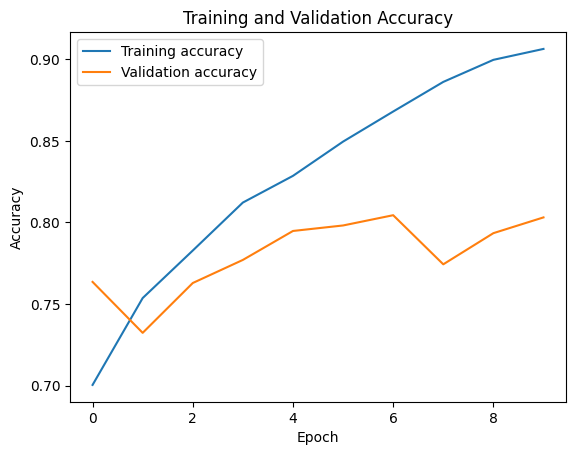

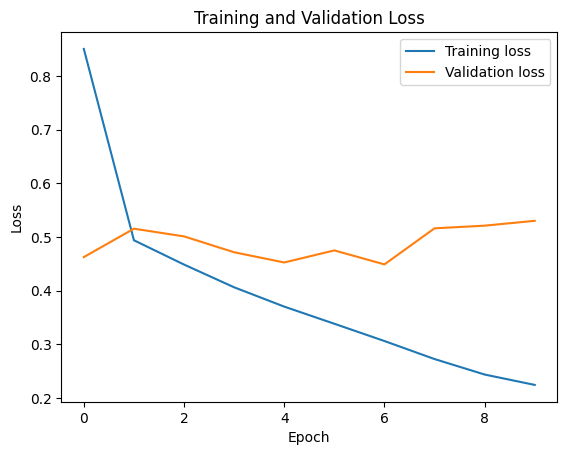

In [49]:
# =========================
# PLOT TRAINING CURVES
# =========================

plt.figure()
plt.plot(history.history["accuracy"], label="Training accuracy")
plt.plot(history.history["val_accuracy"], label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Training and Validation Accuracy")
plt.show()

plt.figure()
plt.plot(history.history["loss"], label="Training loss")
plt.plot(history.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training and Validation Loss")
plt.show()

In [50]:
# =========================
# EVALUATE ON TEST SET
# =========================

test_loss, test_accuracy = model.evaluate(test_gen)

print("Test loss:", test_loss)
print("Test accuracy:", test_accuracy)

140/140 ━━━━━━━━━━━━━━━━━━━━ 297s 2s/step - accuracy: 0.8082 - loss: 0.5066
Test loss: 0.5065891146659851
Test accuracy: 0.8082191944122314


In [51]:
# =========================
# CONFUSION MATRIX AND CLASSIFICATION REPORT
# =========================

predictions = model.predict(test_gen)
predicted_classes = (predictions > 0.5).astype(int).reshape(-1)

true_classes = test_labels

print("Confusion matrix:")
print(confusion_matrix(true_classes, predicted_classes))

print("\nClassification report:")
print(classification_report(
    true_classes,
    predicted_classes,
    target_names=["not_pneumonia", "pneumonia"]
))

140/140 ━━━━━━━━━━━━━━━━━━━━ 288s 2s/step
Confusion matrix:
[[2918  469]
 [ 385  681]]

Classification report:
               precision    recall  f1-score   support

not_pneumonia       0.88      0.86      0.87      3387
    pneumonia       0.59      0.64      0.61      1066

     accuracy                           0.81      4453
    macro avg       0.74      0.75      0.74      4453
 weighted avg       0.81      0.81      0.81      4453



In [52]:
# =========================
# SINGLE IMAGE PREDICTION
# =========================

def predict_single_dicom(file_path):
    img = load_preprocess_dicom_vgg16(file_path)
    img = np.expand_dims(img, axis=0)

    prediction = model.predict(img)[0][0]

    if prediction > 0.5:
        label = "pneumonia"
    else:
        label = "not_pneumonia"

    print("Prediction:", label)
    print("Raw probability:", prediction)

    return label, prediction

In [53]:
example_path = test_paths[0]
predict_single_dicom(example_path)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 288ms/step
Prediction: not_pneumonia
Raw probability: 0.072934896


('not_pneumonia', np.float32(0.072934896))

In [54]:
thresholds = [0.5, 0.4, 0.3, 0.2]

predictions = model.predict(test_gen)
true_classes = test_labels

for threshold in thresholds:
    predicted_classes = (predictions > threshold).astype(int).reshape(-1)

    print("=" * 50)
    print("Threshold:", threshold)
    print("Confusion matrix:")
    print(confusion_matrix(true_classes, predicted_classes))

    print("\nClassification report:")
    print(classification_report(
        true_classes,
        predicted_classes,
        target_names=["not_pneumonia", "pneumonia"]
    ))

140/140 ━━━━━━━━━━━━━━━━━━━━ 287s 2s/step
Threshold: 0.5
Confusion matrix:
[[2918  469]
 [ 385  681]]

Classification report:
               precision    recall  f1-score   support

not_pneumonia       0.88      0.86      0.87      3387
    pneumonia       0.59      0.64      0.61      1066

     accuracy                           0.81      4453
    macro avg       0.74      0.75      0.74      4453
 weighted avg       0.81      0.81      0.81      4453

Threshold: 0.4
Confusion matrix:
[[2794  593]
 [ 326  740]]

Classification report:
               precision    recall  f1-score   support

not_pneumonia       0.90      0.82      0.86      3387
    pneumonia       0.56      0.69      0.62      1066

     accuracy                           0.79      4453
    macro avg       0.73      0.76      0.74      4453
 weighted avg       0.81      0.79      0.80      4453

Threshold: 0.3
Confusion matrix:
[[2650  737]
 [ 268  798]]

Classification report:
               precision    recall  f1-s